# Credit Card Fraud Detection — Exploration

This notebook covers Phases 1 and 2: understanding the data and preprocessing it for modeling.

## Phase 1 — Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure output directories exist
Path('../outputs/figures').mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../data/creditcard.csv')

print('Shape:', df.shape)
print()
print('Columns:', df.columns.tolist())
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Null counts:')
print(df.isnull().sum())

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Null counts:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13 

In [3]:
# Class balance
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

balance = pd.DataFrame({'Count': class_counts, 'Percentage': class_pct.round(4)})
balance.index = ['Legitimate (0)', 'Fraud (1)']
print('Class Balance:')
print(balance)

Class Balance:
                 Count  Percentage
Legitimate (0)  284315     99.8273
Fraud (1)          492      0.1727


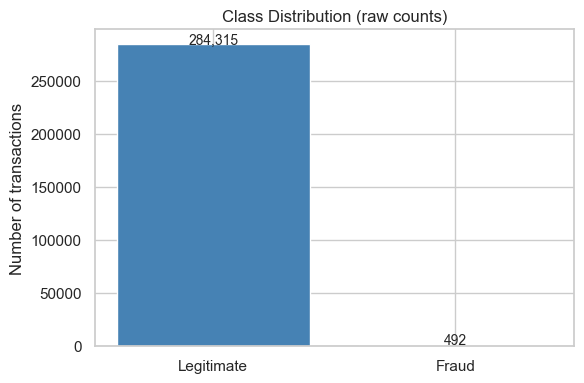

Saved: outputs/figures/class_distribution.png


In [4]:
# Plot 1 — Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'], class_counts.values, color=['steelblue', 'crimson'])
ax.set_title('Class Distribution (raw counts)')
ax.set_ylabel('Number of transactions')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()
print('Saved: outputs/figures/class_distribution.png')

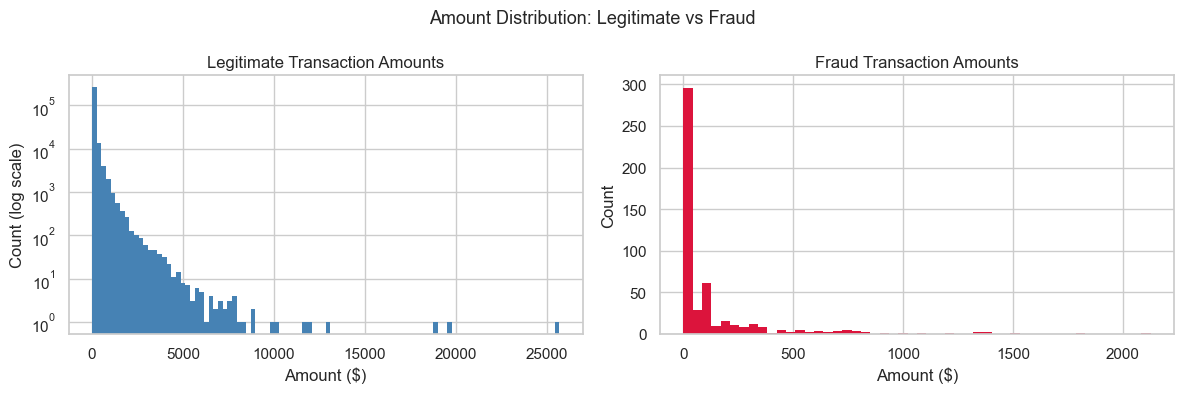

Legit  — mean: $88.29, median: $22.00, max: $25691.16
Fraud  — mean: $122.21, median: $9.25, max: $2125.87
Saved: outputs/figures/amount_distribution.png


In [5]:
# Plot 2 — Amount distribution: fraud vs legitimate
legit = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(legit, bins=100, color='steelblue', edgecolor='none', log=True)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count (log scale)')

axes[1].hist(fraud, bins=50, color='crimson', edgecolor='none')
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')

plt.suptitle('Amount Distribution: Legitimate vs Fraud', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/amount_distribution.png', dpi=150)
plt.show()

print(f'Legit  — mean: ${legit.mean():.2f}, median: ${legit.median():.2f}, max: ${legit.max():.2f}')
print(f'Fraud  — mean: ${fraud.mean():.2f}, median: ${fraud.median():.2f}, max: ${fraud.max():.2f}')
print('Saved: outputs/figures/amount_distribution.png')

## Phase 2 — Preprocessing

**Why scale `Amount` and `Time` but NOT `V1`–`V28`?**

`V1`–`V28` are the result of PCA (Principal Component Analysis) — the dataset authors already applied a transformation that both reduces dimensionality and standardizes scale. Re-scaling them would distort what PCA produced and add no value.

`Amount` and `Time` are raw. `Amount` ranges from \$0 to \$25,691 — a model trained without scaling would treat a \$25,000 transaction as mathematically 25,000× more "important" than a \$1 transaction, purely because of magnitude. `StandardScaler` removes that bias by centering each feature at 0 with unit variance.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale only Amount and Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df_model = df.drop(columns=['Amount', 'Time'])

X = df_model.drop(columns=['Class'])
y = df_model['Class']

print('Features shape:', X.shape)
print('Target shape:  ', y.shape)

Features shape: (284807, 30)
Target shape:   (284807,)


**Why stratified split?**

With a plain random split on heavily imbalanced data, you could get unlucky: by chance, your test set might end up with far fewer (or even zero) fraud cases. Then your evaluation is meaningless because you're not testing on a representative sample. Stratified split forces the train and test sets to each have the same fraud percentage as the full dataset (~0.17%), so evaluation is always on a fair sample.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_fraud_pct = y_train.mean() * 100
test_fraud_pct  = y_test.mean() * 100
overall_pct     = y.mean() * 100

print(f'Overall fraud rate:    {overall_pct:.4f}%')
print(f'Train  fraud rate:     {train_fraud_pct:.4f}%')
print(f'Test   fraud rate:     {test_fraud_pct:.4f}%')
print()
print(f'Train size: {len(X_train):,} rows  |  fraud cases: {y_train.sum()}')
print(f'Test  size: {len(X_test):,}  rows  |  fraud cases: {y_test.sum()}')

Overall fraud rate:    0.1727%
Train  fraud rate:     0.1729%
Test   fraud rate:     0.1720%

Train size: 227,845 rows  |  fraud cases: 394
Test  size: 56,962  rows  |  fraud cases: 98
